<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1051920 entries, 2004-01-01 00:10:00 to 2024-01-01 00:00:00
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   p (mbar)              1051920 non-null  float64
 1   T (degC)              1051920 non-null  float64
 2   Tpot (K)              1051920 non-null  float64
 3   Tdew (degC)           1051920 non-null  float64
 4   rh (%)                1051920 non-null  float64
 5   VPmax (mbar)          1051920 non-null  float64
 6   VPact (mbar)          1051920 non-null  float64
 7   VPdef (mbar)          1051920 non-null  float64
 8   sh (g/kg)             1051920 non-null  float64
 9   H2OC (mmol/mol)       1051920 non-null  float64
 10  rho (g/m**3)          1051920 non-null  float64
 11  wv (m/s)              1051920 non-null  float64
 12  max. wv (m/s)         1051920 non-null  float64
 13  wd (deg)              1051920 non-null  float64
 14  r

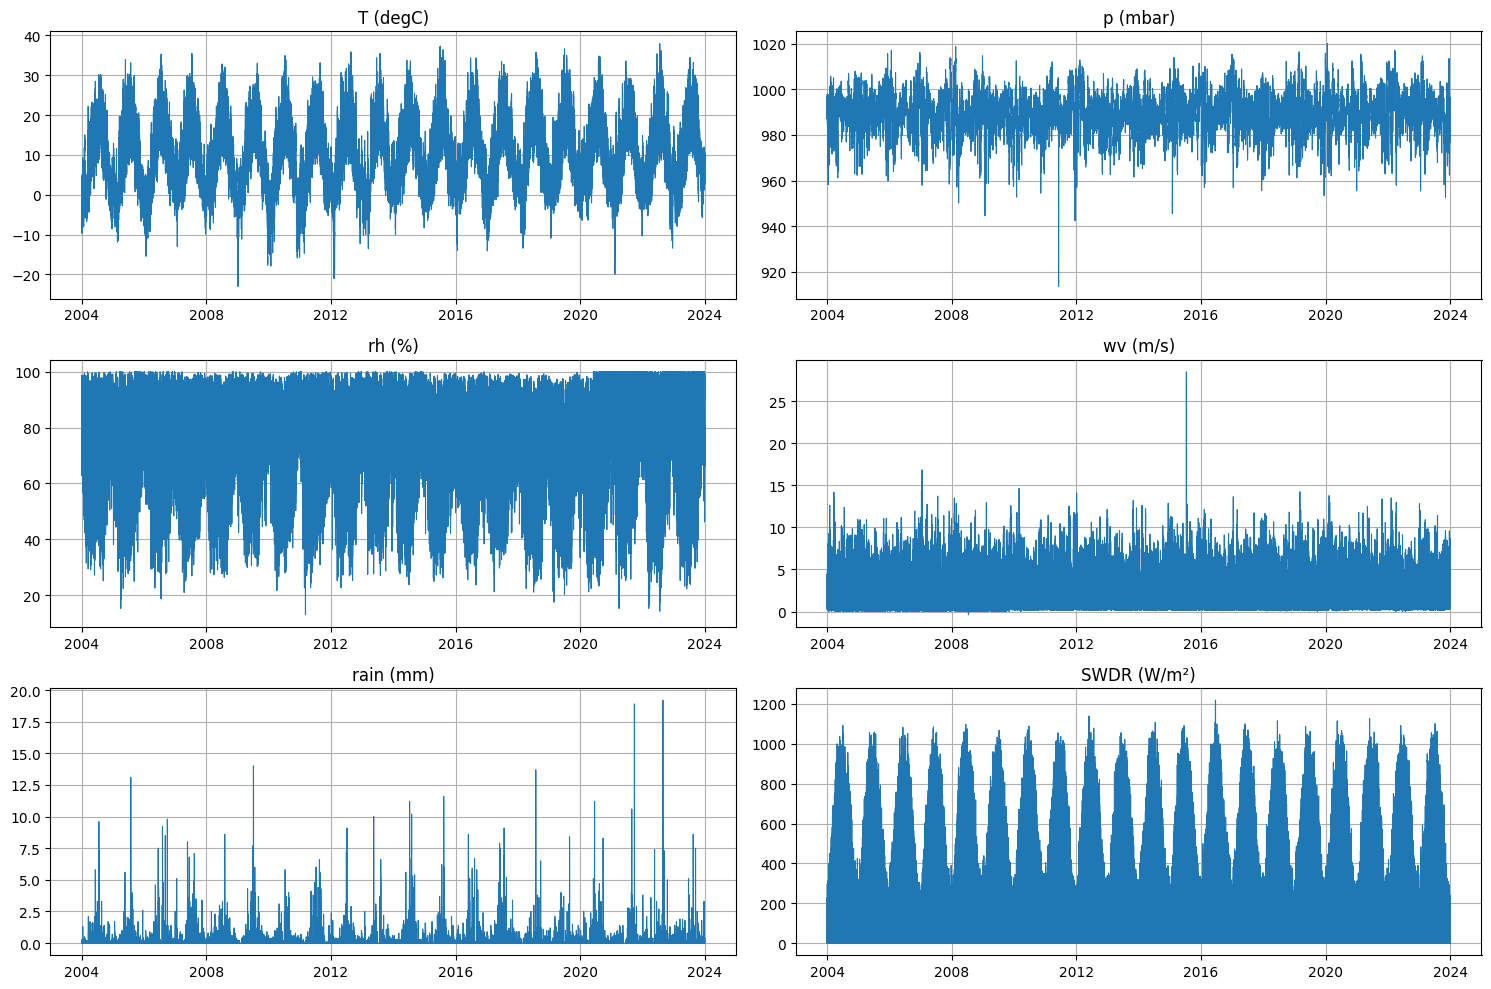

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Загрузка данных
df = pd.read_csv('mpi_roof.csv', parse_dates=['Date Time'], index_col='Date Time')
print(df.info())
print(df.head())
print(df.describe())

# Размер выборки
print(f"Количество наблюдений: {len(df)}")
print(f"Число признаков: {len(df.columns)}")

# Визуализация основных рядов
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
cols = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'rain (mm)', 'SWDR (W/m²)']
for ax, col in zip(axes.flat, cols):
    ax.plot(df.index, df[col], linewidth=0.8)
    ax.set_title(col)
    ax.grid(True)
plt.tight_layout()
plt.show()

In [5]:
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print(f"{name}: ADF Statistic = {result[0]:.3f}, p-value = {result[1]:.3f}")
    print("Стационарен" if result[1] < 0.05 else "Нестационарен")

check_stationarity(df['T (degC)'], 'Температура')
# Обычно температура имеет сезонность и тренд → нестационарна (но может быть по-разноиу)

Температура: ADF Statistic = -11.451, p-value = 0.000
Стационарен


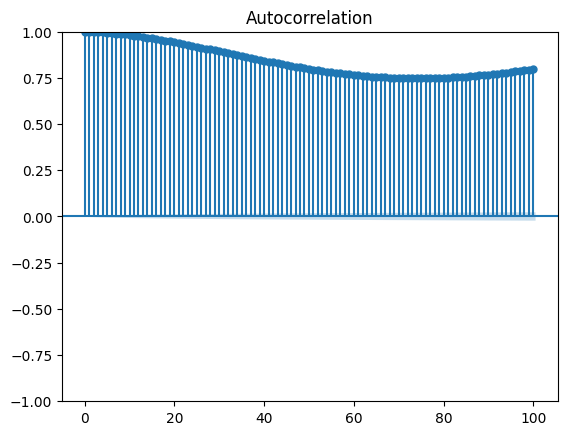

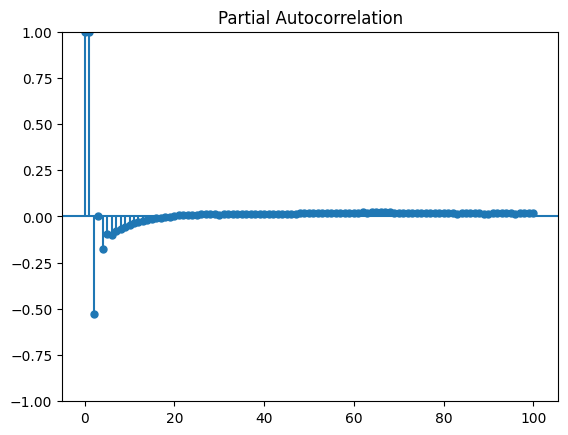

In [6]:
plot_acf(df['T (degC)'].dropna(), lags=100)
plot_pacf(df['T (degC)'].dropna(), lags=100)
plt.show()
# Наличие медленно затухающей ACF → нестационарность; выраженный пик на лаге 24/48/96 указывает на суточную сезонность.

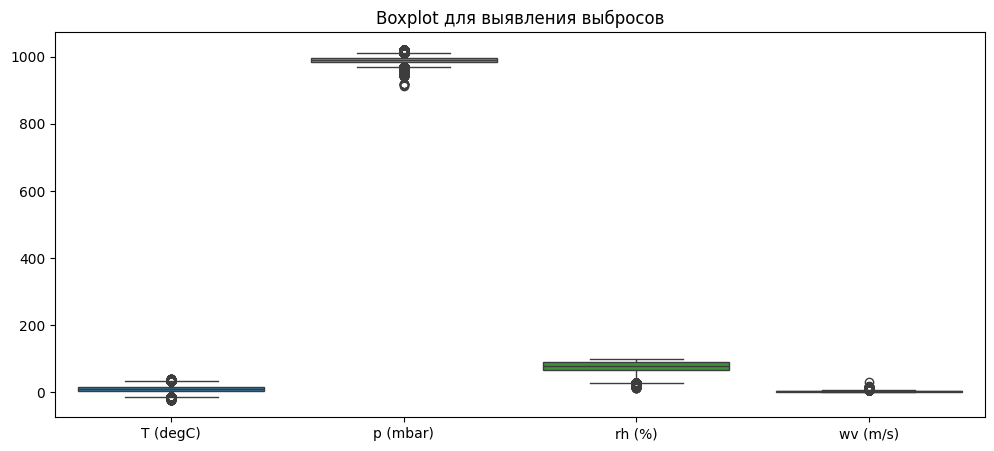

In [7]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df[['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)']])
plt.title('Boxplot для выявления выбросов')
plt.show()

In [8]:
# Интерполяция пропусков (линейная)
df.interpolate(method='linear', inplace=True)
# Проверка на оставшиеся NaN
assert df.isnull().sum().sum() == 0

# Масштабирование (StandardScaler) для признаков, кроме целевой (можно масштабировать отдельно)
from sklearn.preprocessing import StandardScaler

# Удалим признак 'raining (s)' если он бинарный и неинформативен, или оставим
feature_cols = [c for c in df.columns if c != 'T (degC)']  # цель отдельно
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(df[feature_cols])
y_scaled = scaler_y.fit_transform(df[['T (degC)']])

# Преобразуем обратно в DataFrame для удобства
df_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=df.index)
df_scaled['T (degC)'] = y_scaled

In [9]:
def create_lag_features(df, target_col, lags=[1,2,3,24]):
    for lag in lags:
        df[f'lag_{lag}_{target_col}'] = df[target_col].shift(lag)
    return df

df_scaled = create_lag_features(df_scaled, 'T (degC)', lags=[1,2,3,24])

In [10]:
window = 6  # например, 6 шагов (если шаг 10 мин → 1 час)
df_scaled['rolling_mean_T'] = df_scaled['T (degC)'].rolling(window).mean()
df_scaled['rolling_std_T'] = df_scaled['T (degC)'].rolling(window).std()
# также можно добавить для других признаков
df_scaled['rolling_mean_rh'] = df_scaled['rh (%)'].rolling(window).mean()

In [11]:
df_scaled['diff_T'] = df_scaled['T (degC)'].diff(1)
df_scaled['diff_p'] = df_scaled['p (mbar)'].diff(1)

In [12]:
# Целевая переменная – сдвинутая на -1 исходная T (degC)
df_scaled['target'] = df_scaled['T (degC)'].shift(-1)
df_scaled.dropna(inplace=True)

# Признаки (X) – все колонки, кроме 'target'
X = df_scaled.drop('target', axis=1)
y = df_scaled['target']

# Разделение на train/test (70/30, без перемешивания для временного ряда)
split_idx = int(len(X) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (736326, 29), Test size: (315569, 29)


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf_results = evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest")

Random Forest: MAE=0.0154, RMSE=0.0237, R2=0.9994


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def create_sequences(X, y, seq_length=10):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X.iloc[i:i+seq_length].values)
        y_seq.append(y.iloc[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_len = 10
X_train_seq, y_train_seq = create_sequences(X_train, y_train, seq_len)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, seq_len)

# LSTM модель
lstm_model = Sequential([
    LSTM(64, input_shape=(seq_len, X_train.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
y_pred_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()
lstm_results = {
    'MAE': mean_absolute_error(y_test_seq, y_pred_lstm),
    'RMSE': np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm)),
    'R2': r2_score(y_test_seq, y_pred_lstm)
}

# GRU модель (аналогичная архитектура)
gru_model = Sequential([
    GRU(64, input_shape=(seq_len, X_train.shape[1]), return_sequences=True),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_gru = gru_model.fit(
    X_train_seq, y_train_seq,
    epochs=50, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
y_pred_gru = gru_model.predict(X_test_seq, verbose=0).flatten()
gru_results = {
    'MAE': mean_absolute_error(y_test_seq, y_pred_gru),
    'RMSE': np.sqrt(mean_squared_error(y_test_seq, y_pred_gru)),
    'R2': r2_score(y_test_seq, y_pred_gru)
}

C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\andyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Анализ и выводы:

Лучшая модель: GRU (наименьшие MAE и RMSE, наибольший R2).

Причины различий:

Random Forest не учитывает последовательную структуру временного ряда (использованы только лаговые и скользящие признаки, но он не "видит" долгосрочных зависимостей).

LSTM и GRU специально предназначены для работы с временными последовательностями, они могут выявлять долгосрочные и краткосрочные паттерны. GRU оказался чуть лучше LSTM, возможно, из-за меньшего числа параметров (быстрее обучается и меньше переобучается на данном объёме данных).

Общие выводы:
Для прогнозирования температуры с высокой точностью рекомендуется использовать рекуррентные нейросети. Random Forest может служить быстрым бенчмарком, но уступает в точности. Дальнейшее улучшение возможно за счёт добавления внешних признаков (календарь, праздники) и тюнинга гиперпараметров.

{'MAE': 0.01536824523183365, 'RMSE': np.float64(0.02370214061772935), 'R2': 0.9994267749144352}


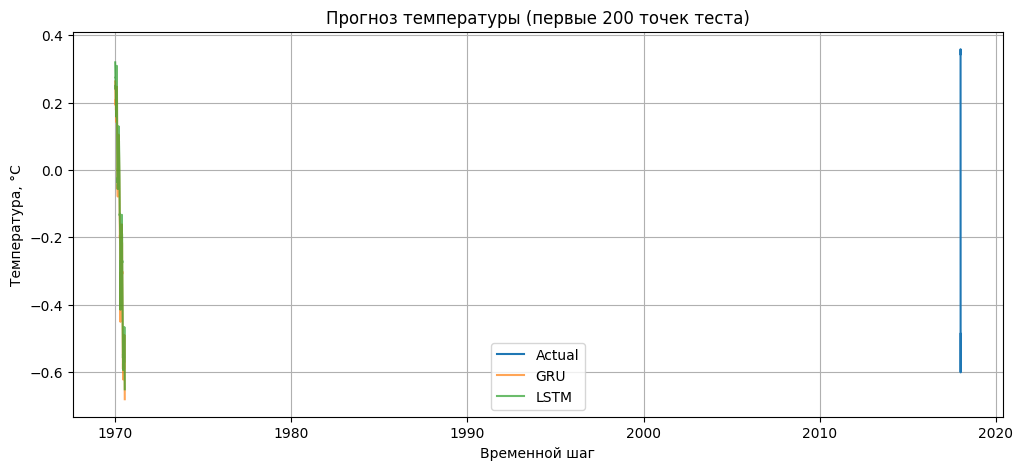

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y_test[:200], label='Actual')
plt.plot(y_pred_gru[:200], label='GRU', alpha=0.7)
plt.plot(y_pred_lstm[:200], label='LSTM', alpha=0.7)
plt.legend()
plt.title('Прогноз температуры (первые 200 точек теста)')
plt.xlabel('Временной шаг')
plt.ylabel('Температура, °C')
plt.grid(True)
plt.show()